## Overview

**This guide presents a basic implementation of Logistic Regression intended to help students understand the fundamental workflow involved in building a machine learning model for classification tasks.**

#### Important Notes and Instructions

- This implementation follows a procedural programming approach. Functional programming concepts have not been adopted in this guide.

- You are required to reproduce all codes exactly as presented, particularly the sections related to data visualisation and model evaluation. Also explore the documentation provided to learn more.

- Do not copy and paste the codes. Which means, you must type the code manually to ensure that you fully understand each step and develop hands-on proficiency with the implementation process.

- The code includes clear and descriptive comments to guide you through: Data preprocessing steps. model training, evaluation and visualisation

- References to relevant documentation and learning resources are provided throughout the notebook.
You are strongly encouraged to explore these resources to deepen your understanding beyond this exercise.

Visit: `https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html`

Dataset is available at: `https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15`, `https://research.unsw.edu.au/projects/unsw-nb15-dataset`

In [1]:
# Third-Party Libraries (General Data Science/Utilities)
import numpy as np
import pandas as pd

# Visualization Libraries
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import random

# Set random seed for reproducibility
RANDOM_SEED = 2 # Last digit of your student ID
SPLIT_PERCENT = (0.05 * RANDOM_SEED) + 25
TEST_SIZE = round(SPLIT_PERCENT / 100, 2)


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Random Seed: {RANDOM_SEED}")
print(f"Test Size: {TEST_SIZE}")

Random Seed: 42
Test Size: 0.27


In [3]:
# Set path to data and results directory

from pathlib import Path

data_dir = Path("../datasets/UNSW-NB15/")
results_dir = Path("../results/logistic_regression/") 
results_dir.mkdir(parents=True, exist_ok=True)

# Visit "https://docs.python.org/3/library/pathlib.html" for more info on pathlib

In [4]:
# Load the features file to get feature names
# The features file is available at "../datasets/UNSW-NB15/NUSW-NB15_features.csv"
# The encoding is "cp1252" to handle special characters
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html" for more info on pd.read_csv

features = pd.read_csv(data_dir / "NUSW-NB15_features.csv", 
                        encoding="cp1252")
features

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [5]:
# Load the first part of the UNSW-NB15 dataset
# The dataset file is available at "../datasets/UNSW-NB15/UNSW-NB15_1.csv"
# The encoding is "cp1252" to handle special characters

data_file_one = pd.read_csv(data_dir / "UNSW-NB15_1.csv", 
                    encoding="cp1252", 
                    names=features.Name.unique())

data_file_one.head()

/tmp/ipykernel_44199/2486365522.py:5: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  data_file_one = pd.read_csv(data_dir / "UNSW-NB15_1.csv",


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,ï»¿59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0


In [6]:
# Load the second part of the UNSW-NB15 dataset
# The dataset file is available at "../datasets/UNSW-NB15/UNSW-NB15_2.csv"
# The encoding is "cp1252" to handle special characters

data_file_two = pd.read_csv(data_dir / "UNSW-NB15_2.csv", 
                    encoding="cp1252", 
                    names=features.Name.unique())

data_file_two.head()

/tmp/ipykernel_44199/1852423826.py:5: DtypeWarning: Columns (3,39,47) have mixed types. Specify dtype option on import or set low_memory=False.
  data_file_two = pd.read_csv(data_dir / "UNSW-NB15_2.csv",


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,6055,149.171.126.5,54145,tcp,FIN,0.072974,4238,60788,31,...,0,13,13,6,7,1,1,2,NaN,0
1,59.166.0.0,7832,149.171.126.3,5607,tcp,FIN,0.144951,5174,91072,31,...,0,13,13,6,7,1,1,2,NaN,0
2,59.166.0.8,11397,149.171.126.6,21,tcp,FIN,0.116107,2934,3742,31,...,1,1,2,7,5,1,1,4,NaN,0
3,59.166.0.0,3804,149.171.126.3,53,udp,CON,0.000986,146,178,31,...,0,13,13,6,7,1,1,2,NaN,0
4,59.166.0.8,14339,149.171.126.6,14724,tcp,FIN,0.038480,8928,320,31,...,0,8,20,7,5,1,1,4,NaN,0


In [7]:
# # Load the third part of the UNSW-NB15 dataset
data_file_three = pd.read_csv(data_dir / "UNSW-NB15_3.csv", 
                    encoding="cp1252", 
                    names=features.Name.unique())

data_file_three.head()

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.1,18247,149.171.126.4,7662,tcp,FIN,0.119596,4550,68342,31,...,,6,2,2,5,1,1,2,NaN,0
1,59.166.0.3,54771,149.171.126.2,27709,tcp,FIN,0.650574,8928,320,31,...,,3,5,2,4,1,1,4,NaN,0
2,59.166.0.8,13289,149.171.126.9,5190,tcp,FIN,0.007980,2158,2464,31,...,,3,5,1,1,1,1,3,NaN,0
3,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,...,,19,19,19,19,19,19,19,NaN,0
4,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,...,,19,19,19,19,19,19,19,NaN,0


In [8]:
# # Load the fourth part of the UNSW-NB15 dataset
data_file_four = pd.read_csv(data_dir / "UNSW-NB15_4.csv", 
                    encoding="cp1252", 
                    names=features.Name.unique())

data_file_four.head()

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.9,7045,149.171.126.7,25,tcp,FIN,0.201886,37552,3380,31,...,,2,2,7,4,1,1,3,NaN,0
1,59.166.0.9,9685,149.171.126.2,80,tcp,FIN,5.864748,19410,1087890,31,...,,3,1,4,4,1,1,1,NaN,0
2,59.166.0.2,1421,149.171.126.4,53,udp,CON,0.001391,146,178,31,...,,3,5,2,7,1,1,4,NaN,0
3,59.166.0.2,21553,149.171.126.2,25,tcp,FIN,0.053948,37812,3380,31,...,,1,1,4,7,1,1,3,NaN,0
4,59.166.0.8,45212,149.171.126.4,53,udp,CON,0.000953,146,178,31,...,,2,5,2,1,1,1,2,NaN,0


In [9]:
# Concatenate all four parts of the dataset into a single DataFrame
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.concat.html" for more info on pd.concat

data = pd.concat([data_file_one, 
                  data_file_two, 
                  data_file_three, 
                  data_file_four], axis=0)

In [10]:
# Get data shape
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html" for more info on pd.DataFrame.shape
data.shape

(2540047, 49)

In [11]:
# Get information about the dataset
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html" for more info on pd.DataFrame.info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2540047 entries, 0 to 440043
Data columns (total 49 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             object 
 1   sport             object 
 2   dstip             object 
 3   dsport            object 
 4   proto             object 
 5   state             object 
 6   dur               float64
 7   sbytes            int64  
 8   dbytes            int64  
 9   sttl              int64  
 10  dttl              int64  
 11  sloss             int64  
 12  dloss             int64  
 13  service           object 
 14  Sload             float64
 15  Dload             float64
 16  Spkts             int64  
 17  Dpkts             int64  
 18  swin              int64  
 19  dwin              int64  
 20  stcpb             int64  
 21  dtcpb             int64  
 22  smeansz           int64  
 23  dmeansz           int64  
 24  trans_depth       int64  
 25  res_bdy_len       int64  
 26  Sjit              fl

In [12]:
# Get descriptive statistics of the dataset for numerical columns
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html" for more info on pd.DataFrame.describe
data.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
dur,2540047.0,6.587916e-01,1.392493e+01,0.000000e+00,1.037000e-03,1.586100e-02,2.145545e-01,8.786638e+03
sbytes,2540047.0,4.339600e+03,5.640599e+04,0.000000e+00,2.000000e+02,1.470000e+03,3.182000e+03,1.435577e+07
dbytes,2540047.0,3.642759e+04,1.610960e+05,0.000000e+00,1.780000e+02,1.820000e+03,1.489400e+04,1.465753e+07
sttl,2540047.0,6.278197e+01,7.462277e+01,0.000000e+00,3.100000e+01,3.100000e+01,3.100000e+01,2.550000e+02
dttl,2540047.0,3.076681e+01,4.285089e+01,0.000000e+00,2.900000e+01,2.900000e+01,2.900000e+01,2.540000e+02
sloss,2540047.0,5.163921e+00,2.251707e+01,0.000000e+00,0.000000e+00,3.000000e+00,7.000000e+00,5.319000e+03
dloss,2540047.0,1.632944e+01,5.659474e+01,0.000000e+00,0.000000e+00,4.000000e+00,1.400000e+01,5.507000e+03
Sload,2540047.0,3.695645e+07,1.186043e+08,0.000000e+00,1.353963e+05,5.893038e+05,2.039923e+06,5.988000e+09
Dload,2540047.0,2.450861e+06,4.224863e+06,0.000000e+00,1.191594e+04,5.893179e+05,2.925974e+06,1.287619e+08
Spkts,2540047.0,3.328884e+01,7.628388e+01,0.000000e+00,2.000000e+00,1.200000e+01,4.400000e+01,1.064600e+04


In [13]:
# Get descriptive statistics of the dataset for categorical columns
data.describe(include=['object', 'category']).T

,count,unique,top,freq
srcip,2540047,44,59.166.0.4,197959
sport,2540047,100341,1043,216289
dstip,2540047,47,149.171.126.3,197771
dsport,2540047,128297,53,619538
proto,2540047,135,tcp,1495074
state,2540047,16,FIN,1478689
service,2540047,13,-,1246397
ct_ftp_cmd,2540047,13,,1429879
attack_cat,321283,13,Generic,215481


In [14]:
# Get unique labels in the 'Label' column
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unique.html" for more info on pd.Series.unique
data.Label.unique()

array([0, 1])

In [15]:
# Get unique attack categories in the 'attack_cat' column
data.attack_cat.unique()

array([nan, 'Exploits', 'Reconnaissance', 'DoS', 'Generic', 'Shellcode',
       ' Fuzzers', 'Worms', 'Backdoors', 'Analysis', ' Reconnaissance ',
       'Backdoor', ' Fuzzers ', ' Shellcode '], dtype=object)

In [16]:
# Get counts of each label in the 'Label' column
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html" for more info on pd.Series.value_counts
data.Label.value_counts()

Label
0    2218764
1     321283
Name: count, dtype: int64

In [17]:
# Get counts of each attack category in the 'attack_cat' column
data.attack_cat.value_counts()

attack_cat
Generic             215481
Exploits             44525
 Fuzzers             19195
DoS                  16353
 Reconnaissance      12228
 Fuzzers              5051
Analysis              2677
Backdoor              1795
Reconnaissance        1759
 Shellcode            1288
Backdoors              534
Shellcode              223
Worms                  174
Name: count, dtype: int64

In [18]:
# Subsample the data for quicker experimentation
# Here, we randomly sample 100,000 rows from the dataset
## Uncomment the line below to enable subsampling
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html" for more info on pd.DataFrame.sample

# data = data.sample(100000, random_state=42)

In [19]:
# Verify the subsampling
data.Label.value_counts()

Label
0    2218764
1     321283
Name: count, dtype: int64

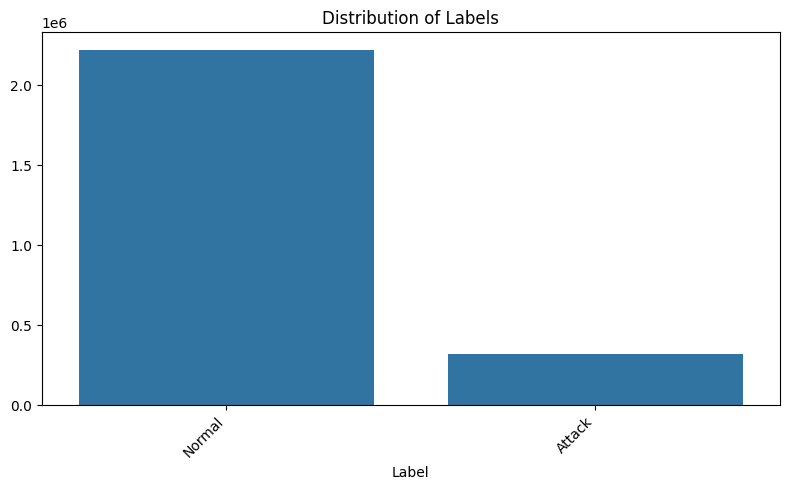

In [20]:
# Visualize the distribution of labels in the dataset
# Visit "https://seaborn.pydata.org/generated/seaborn.barplot.html" for more info on sns.barplot

label_counts = data.Label.value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values) 
plt.title("Distribution of Labels")
plt.xticks(ticks=[0, 1], labels=["Normal", "Attack"], rotation=45, ha="right")
plt.tight_layout()
plt.savefig(results_dir /"label_distribution.png", dpi=400)
plt.show()

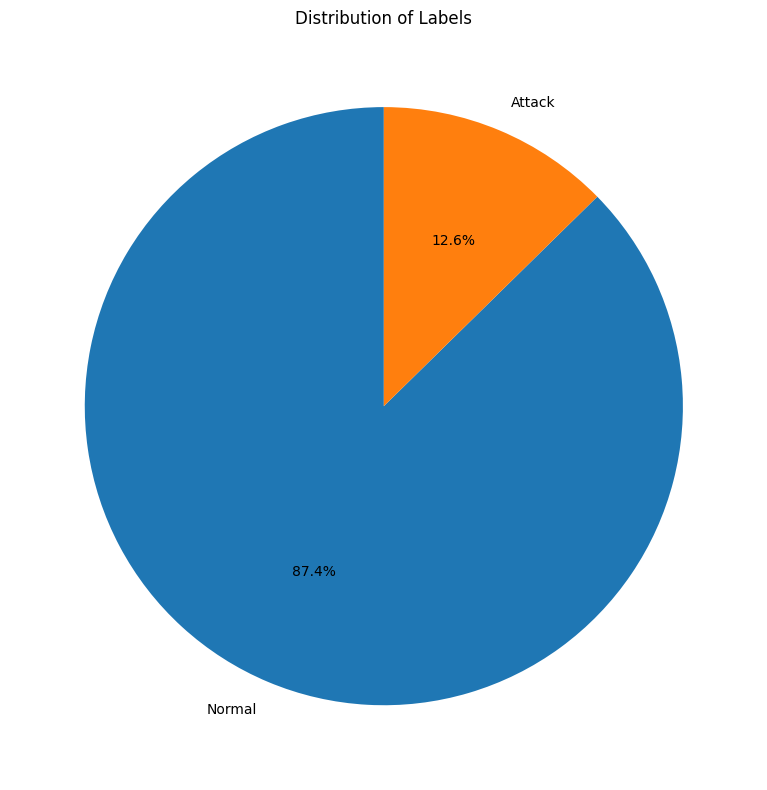

In [21]:
# Visualize the distribution of labels using a pie chart
# Visit "https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html" for more info on plt.pie

# Calculate label counts
label_counts = data.Label.value_counts()

# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    label_counts.values,
    labels=['Normal', 'Attack'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Labels")
plt.tight_layout()
plt.savefig(results_dir /"label_distribution_pie.png", dpi=400)
plt.show()

In [22]:
# Get unique attack categories in the 'attack_cat' column
data.attack_cat.unique()

array([nan, 'Exploits', 'Reconnaissance', 'DoS', 'Generic', 'Shellcode',
       ' Fuzzers', 'Worms', 'Backdoors', 'Analysis', ' Reconnaissance ',
       'Backdoor', ' Fuzzers ', ' Shellcode '], dtype=object)

In [23]:
# Remove spaces in the 'attack_cat' column
data['attack_cat'] = data['attack_cat'].str.strip()
data.attack_cat.unique()

array([nan, 'Exploits', 'Reconnaissance', 'DoS', 'Generic', 'Shellcode',
       'Fuzzers', 'Worms', 'Backdoors', 'Analysis', 'Backdoor'],
      dtype=object)

In [24]:
# Verify the counts of each attack category after stripping spaces
data.attack_cat.value_counts()

attack_cat
Generic           215481
Exploits           44525
Fuzzers            24246
DoS                16353
Reconnaissance     13987
Analysis            2677
Backdoor            1795
Shellcode           1511
Backdoors            534
Worms                174
Name: count, dtype: int64

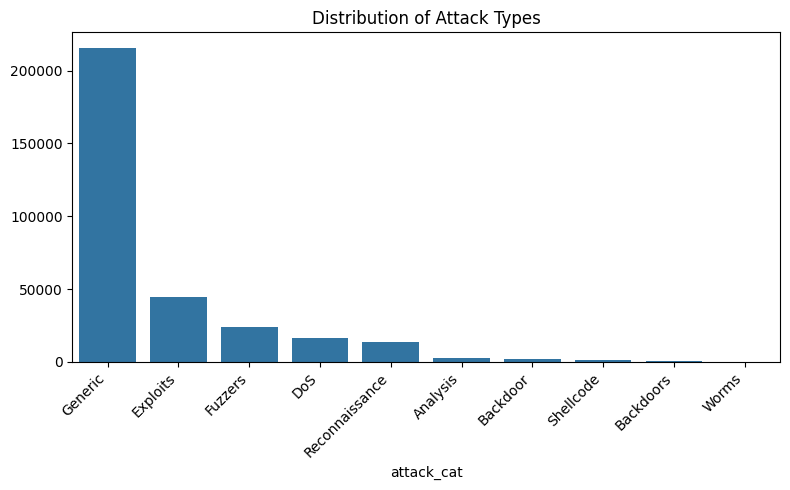

In [25]:
# Get counts of each attack category in the 'attack_cat' column
# This is useful for visualizing the distribution of different attack types in multi-class classification
attack_counts = data.attack_cat.value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=attack_counts.index, y=attack_counts.values) 
plt.title("Distribution of Attack Types")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(results_dir /"attack_types_distribution1.png", dpi=400)
plt.show()

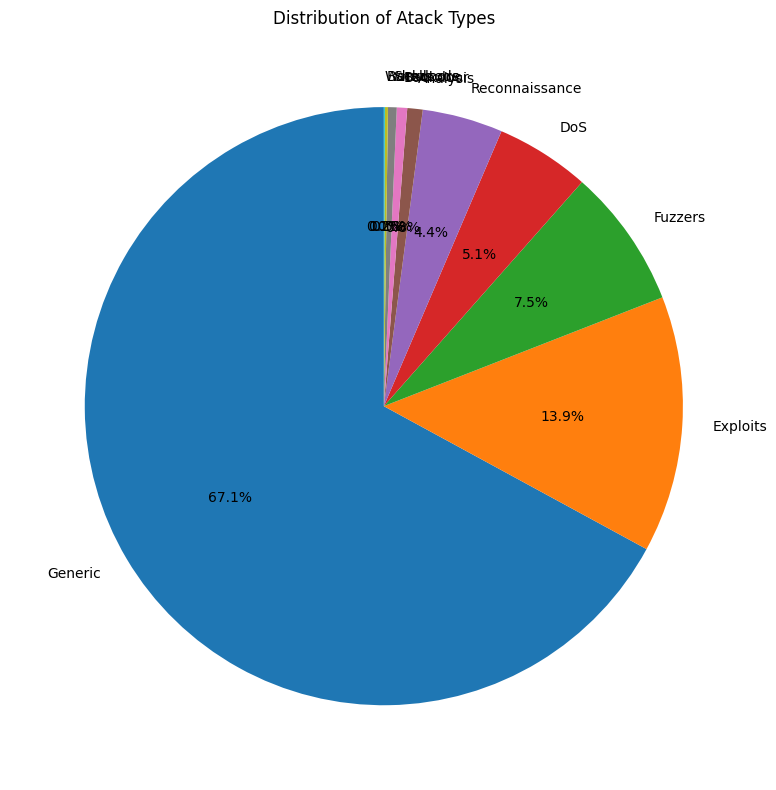

In [26]:
# Visualise the distribution of attack types using a pie chart
# Useful for understanding the proportion of each attack type in the dataset

# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    attack_counts.values,
    labels=attack_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Atack Types")
plt.tight_layout()
plt.savefig(results_dir /"attack_distribution_pie1.png", dpi=400)
plt.show()

In [27]:
# Select only the 'Label' and 'attack_cat' columns for further analysis
# Notice the existence of NaN values in the 'attack_cat' column for normal traffic
attack_label = data[["Label", "attack_cat"]]
attack_label.head()

,Label,attack_cat
0,0,NaN
1,0,NaN
2,0,NaN
3,0,NaN
4,0,NaN


In [28]:
# Select attack_cat where label is 0
zero_label_attacks = attack_label[attack_label['Label'] == 0]['attack_cat']
zero_label_attacks.head(10)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
Name: attack_cat, dtype: object

In [29]:
# Rename all Attack Category with NaN to Benign
# This should only happen if Attack
data.loc[(data['Label'] == 0) & (data['attack_cat'].isna()), 'attack_cat'] = 'Benign'
data[["Label", "attack_cat"]].head(20)

,Label,attack_cat
0,0,Benign
1,0,Benign
2,0,Benign
3,0,Benign
4,0,Benign
5,0,Benign
6,0,Benign
7,0,Benign
8,0,Benign
9,0,Benign


In [30]:
# Get unique attack categories in the 'attack_cat' column again
data.attack_cat.unique()

array(['Benign', 'Exploits', 'Reconnaissance', 'DoS', 'Generic',
       'Shellcode', 'Fuzzers', 'Worms', 'Backdoors', 'Analysis',
       'Backdoor'], dtype=object)

In [31]:
# Get counts of each attack category in the 'attack_cat' column
data.attack_cat.value_counts()

attack_cat
Benign            2218764
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoor             1795
Shellcode            1511
Backdoors             534
Worms                 174
Name: count, dtype: int64

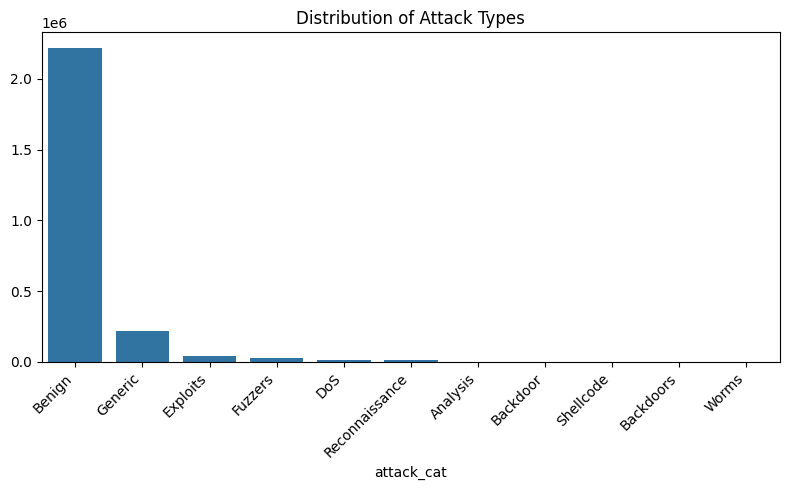

In [32]:
# Visualize the distribution of attack types again after cleaning
attack_counts = data.attack_cat.value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=attack_counts.index, y=attack_counts.values) 
plt.title("Distribution of Attack Types")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(results_dir /"attack_types_distribution2.png", dpi=400)
plt.show()

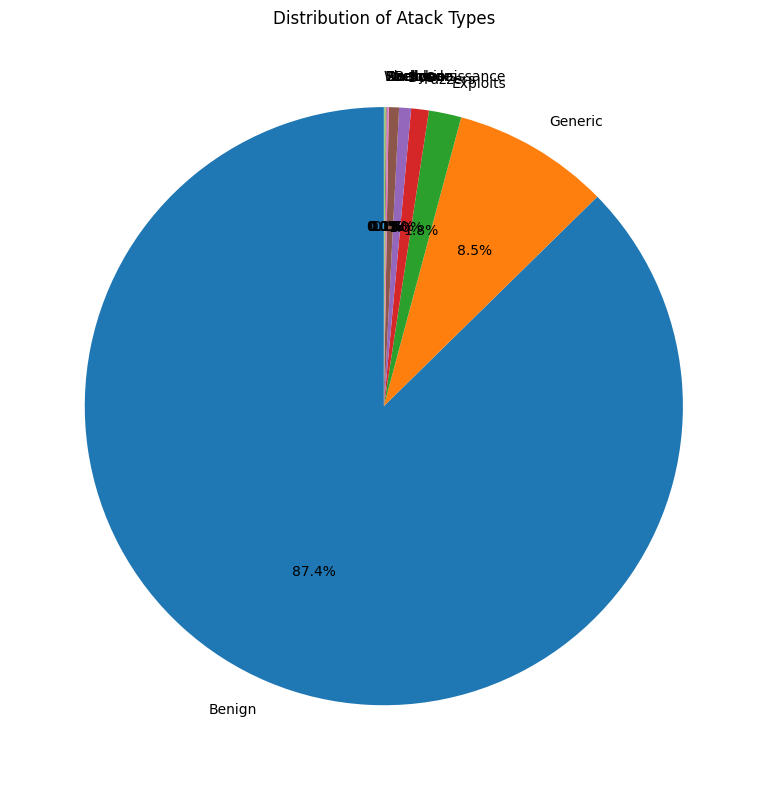

In [33]:
# VIsualize the distribution of attack types using a pie chart again
# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    attack_counts.values,
    labels=attack_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Atack Types")
plt.tight_layout()
plt.savefig(results_dir/ "attack_distribution_pie2.png", dpi=400)
plt.show()

In [34]:
# data.drop("Label", axis= 1, inplace=True)

### Preprocessing

In [35]:
data[["sport", "sport"]].head()

,sport,sport
0,1390,1390
1,33661,33661
2,1464,1464
3,3593,3593
4,49664,49664


In [36]:
# Remove spaces in the 'sport' and 'dsport' columns
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.Series.str.strip.html" for more info on pd.Series.str.strip
data["sport"] = data["sport"].astype(str).str.strip()
data["dsport"] = data["dsport"].astype(str).str.strip()

# Convert 'sport' and 'dsport' columns to numeric, coercing errors to NaN, 
# then filling NaN with 0 and converting to int
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html" for more info on pd.to_numeric
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.Series.fillna.html" for more info on pd.Series.fillna

data["sport"] = pd.to_numeric(data["sport"], errors="coerce").fillna(0).astype(int)
data["dsport"] = pd.to_numeric(data["dsport"], errors="coerce").fillna(0).astype(int)

In [37]:
# Get the unique protocol names in the 'proto' column
data.proto.unique()

array(['udp', 'arp', 'tcp', 'ospf', 'icmp', 'igmp', 'sctp', 'udt', 'sep',
       'sun-nd', 'swipe', 'mobile', 'pim', 'rtp', 'ipnip', 'ip', 'ggp',
       'st2', 'egp', 'cbt', 'emcon', 'nvp', 'igp', 'xnet', 'argus',
       'bbn-rcc', 'chaos', 'pup', 'hmp', 'mux', 'dcn', 'prm', 'trunk-1',
       'xns-idp', 'trunk-2', 'leaf-1', 'leaf-2', 'irtp', 'rdp', 'iso-tp4',
       'netblt', 'mfe-nsp', 'merit-inp', '3pc', 'xtp', 'idpr', 'tp++',
       'ddp', 'idpr-cmtp', 'ipv6', 'il', 'idrp', 'ipv6-frag', 'sdrp',
       'ipv6-route', 'gre', 'rsvp', 'mhrp', 'bna', 'esp', 'i-nlsp',
       'narp', 'ipv6-no', 'tlsp', 'skip', 'ipv6-opts', 'any', 'cftp',
       'sat-expak', 'kryptolan', 'rvd', 'ippc', 'sat-mon', 'ipcv', 'visa',
       'cpnx', 'cphb', 'wsn', 'pvp', 'br-sat-mon', 'wb-mon', 'wb-expak',
       'iso-ip', 'secure-vmtp', 'vmtp', 'vines', 'ttp', 'nsfnet-igp',
       'dgp', 'tcf', 'eigrp', 'sprite-rpc', 'larp', 'mtp', 'ax.25',
       'ipip', 'micp', 'aes-sp3-d', 'encap', 'etherip', 'pri-enc', 'gmtp'

In [38]:
# Encode the 'proto' column using Label Encoding
# Other encoding formats can be used such as One-Hot Encoding 
# depending on the model requirements
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html" for more info on LabelEncoder

from sklearn.preprocessing import LabelEncoder

encoder_tcp = LabelEncoder() # Create LabelEncoder instance

# Fit and transform the 'proto' column
data["proto"] = encoder_tcp.fit_transform(data["proto"])

In [39]:
# Verify the unique values in the 'proto' column after encoding
# Notice how the string "protocol names" have been converted to numerical labels
data.proto.unique()

array([120,   6, 114,  79,  38,  43,  98, 121, 101, 111, 112,  72,  81,
        92,  51,  46,  31, 109,  23,  11,  25,  78,  44, 131,   4,   8,
        13,  87,  34,  74,  19,  85, 117, 132, 118,  66,  67,  59,  90,
        62,  76,  69,  68,   0, 133,  39, 116,  20,  40,  53,  45,  41,
        54,  99,  57,  33,  91,  70,   9,  27,  35,  75,  55, 115, 102,
        56,   3,  12,  94,  63,  93,  52,  95,  48, 125,  16,  15, 130,
        88,  10, 129, 128,  61, 100, 126, 124, 119,  77,  22, 113,  24,
       106,  65,  73,   7,  49,  71,   2,  26,  28,  84,  32,  83,  42,
         5,  89,   1,  97, 105,  47,  14,  58, 127, 134,  80,  36,  21,
        64, 108, 110, 104, 123, 103,  86,  30,  17,  60,  18,  96, 107,
        82,  50, 122,  29,  37])

In [40]:
# Get the unique service names in the 'service' column
data.service.unique()

array(['dns', '-', 'http', 'smtp', 'ftp-data', 'ftp', 'ssh', 'pop3',
       'snmp', 'ssl', 'irc', 'radius', 'dhcp'], dtype=object)

In [41]:
# Fill NaN values in the 'service' column with 'unknown'
data["service"] = data["service"].fillna("unknown")


# Encode the 'service' column using Label Encoding
# Other encoding formats can be used such as One-Hot Encoding 
# depending on the model requirements
encoder_service = LabelEncoder()
data["service"] = encoder_tcp.fit_transform(data["service"])

In [42]:
# Verify the unique values in the 'service' column after encoding
# Notice how the string "service names" have been converted to numerical labels
data.service.unique()

array([ 2,  0,  5,  9,  4,  3, 11,  7, 10, 12,  6,  8,  1])

In [43]:
# Get the unique state names in the 'state' column
data.state.unique()

array(['CON', 'INT', 'FIN', 'URH', 'REQ', 'ECO', 'RST', 'CLO', 'TXD',
       'URN', 'no', 'ACC', 'PAR', 'MAS', 'TST', 'ECR'], dtype=object)

In [44]:
# Encode the 'state' column using Label Encoding
# Other encoding formats can be used such as One-Hot Encoding 
# depending on the model requirements

encoder_state = LabelEncoder()
data["state"] = encoder_tcp.fit_transform(data["state"])

In [45]:
# Get the unique values in the 'ct_ftp_cmd' column after encoding
data.ct_ftp_cmd.unique()

array([0, 1, 6, 2, 4, 8, 5, 3, '0', '1', ' ', '2', '4'], dtype=object)

In [46]:
# Replace spaces with NaN, fill NaN with mean, and convert '1' and '0' strings to integers
# Notice the use of -999 to indicate missing values instead of the mean
data["ct_ftp_cmd"] = data["ct_ftp_cmd"].replace(" ", np.nan).fillna(-999)
data["ct_ftp_cmd"] = data["ct_ftp_cmd"].replace('1',1)
data["ct_ftp_cmd"] = data["ct_ftp_cmd"].replace('0', 0)

In [47]:
# Verify the unique values in the 'ct_ftp_cmd' column after encoding
data.ct_ftp_cmd.unique()

array([0, 1, 6, 2, 4, 8, 5, 3, -999, '2', '4'], dtype=object)

In [48]:
# For this analysis, we will drop the IP address columns
# Drop the source IP 'srcip' and destination IP 'dstip' columns
data.drop(["srcip", "dstip"], axis=1, inplace=True)

In [49]:
# Check for any remaining missing values in the dataset
data.isnull().sum()

sport                     0
dsport                    0
proto                     0
state                     0
dur                       0
sbytes                    0
dbytes                    0
sttl                      0
dttl                      0
sloss                     0
dloss                     0
service                   0
Sload                     0
Dload                     0
Spkts                     0
Dpkts                     0
swin                      0
dwin                      0
stcpb                     0
dtcpb                     0
smeansz                   0
dmeansz                   0
trans_depth               0
res_bdy_len               0
Sjit                      0
Djit                      0
Stime                     0
Ltime                     0
Sintpkt                   0
Dintpkt                   0
tcprtt                    0
synack                    0
ackdat                    0
is_sm_ips_ports           0
ct_state_ttl              0
ct_flw_http_mthd    

In [50]:
# The above indicates that there are still some missing values in the
# 'ct_flw_http_mthd' and 'is_ftp_login' columns.
# We will fill these missing values with the mean of their respective columns

data["ct_flw_http_mthd"] = data["ct_flw_http_mthd"].fillna(data["ct_flw_http_mthd"].mean())
data["is_ftp_login"] = data["is_ftp_login"].fillna(data["is_ftp_login"].mean())

In [51]:
# Verify the remaining missing values after filling
data.isnull().sum()

sport               0
dsport              0
proto               0
state               0
dur                 0
sbytes              0
dbytes              0
sttl                0
dttl                0
sloss               0
dloss               0
service             0
Sload               0
Dload               0
Spkts               0
Dpkts               0
swin                0
dwin                0
stcpb               0
dtcpb               0
smeansz             0
dmeansz             0
trans_depth         0
res_bdy_len         0
Sjit                0
Djit                0
Stime               0
Ltime               0
Sintpkt             0
Dintpkt             0
tcprtt              0
synack              0
ackdat              0
is_sm_ips_ports     0
ct_state_ttl        0
ct_flw_http_mthd    0
is_ftp_login        0
ct_ftp_cmd          0
ct_srv_src          0
ct_srv_dst          0
ct_dst_ltm          0
ct_src_ ltm         0
ct_src_dport_ltm    0
ct_dst_sport_ltm    0
ct_dst_src_ltm      0
attack_cat

In [52]:
# Prepare the feature matrix X and target vector y
# Convert the 'Label' column to binary labels: 'Benign' for 0 and 'ATTACK' for 1
# Though 'Label' is already binary, this makes it explicit for clarity
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html" for more info on pd.Series.apply

data["Label"] = data["Label"].apply(lambda x: "Benign" if x == 0 else "ATTACK")

In [53]:
# Separate the features and target variable
# Drop the 'attack_cat' and 'Label' columns from the feature matrix X
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html" for more info on pd.DataFrame.drop
X = data.drop(["attack_cat", "Label"], axis=1)
y = data["Label"]

In [54]:
# Encode the target variable y using Label Encoding

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print(y)

[1 1 1 ... 1 1 0]


In [55]:
# Get unique values in the target variable y
# Visit "https://numpy.org/doc/stable/reference/generated/numpy.unique.html" for more info on np.unique

np.unique(y)

array([0, 1])

In [56]:
# Check for any NaN values in the target variable y
# Visit "https://numpy.org/doc/stable/reference/generated/numpy.isnan.html" for more info on np.isnan

np.isnan(y).sum()

0

In [57]:
# Split the dataset into training and testing sets
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html" for more info on train_test_split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=TEST_SIZE, 
                                                    stratify=y, # Stratify to maintain class distribution
                                                    random_state=RANDOM_SEED)

In [58]:
# Verify the shapes of the splits
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1854234, 45), (685813, 45), (1854234,), (685813,))

In [59]:
# Get the column names of the feature matrix X_test
# Visit "https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html" for more info on pd.DataFrame.columns

column_names = X_test.columns
column_names

Index(['sport', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl',
       'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts',
       'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth',
       'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt',
       'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
       'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src',
       'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'ct_dst_src_ltm'],
      dtype='object')

In [60]:
# Standardize the feature matrices using StandardScaler
# This ensures that all features have a mean of 0 and a standard deviation of 1
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html" for more info on StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [61]:
# Delete the 'data', 'X', and 'y' variables to free up memory
# Visit "https://docs.python.org/3/library/gc.html" for more info on garbage collection in Python

import gc
del data, X, y
gc.collect()

3900

### Logistic Regression Model Development

In [62]:
# Train a Logistic Regression model
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html" for more info on LogisticRegression

from sklearn.linear_model import LogisticRegression

# Note the use of max_iter=1000 to ensure convergence and
# the random_state for reproducibility

model = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Model Evaluation

In [63]:
# Observe the predicted probabilities for the positive class
# Note that for binary classification, predict_proba returns two columns:
# the probability of the negative class (0) and the positive class (1) 
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba" for more info on predict_proba

y_pred_prob = model.predict_proba(X_test)[:, 1] # Take the second column
y_pred_prob[:20]

array([9.99922370e-01, 1.00000000e+00, 5.50814002e-02, 4.31222905e-03,
       1.00000000e+00, 9.99240537e-01, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 9.99999876e-01, 1.00000000e+00,
       9.99975654e-01, 7.70758490e-04, 9.99941423e-01, 4.96991921e-02,
       9.99922605e-01, 9.99732328e-01, 9.99426002e-01, 9.99947489e-01])

In [64]:
# Make predictions on the test set
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict" for more info on predict

y_pred = model.predict(X_test)
y_pred[:20] # Compare this output with y_pred_prob
# Notice how y_pred contains class labels (0 or 1) while y_pred_prob contains probabilities

array([1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1])

In [65]:
# Calculate the confusion matrix
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html" for more info on confusion_matrix

from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)
cm

array([[ 83899,   2847],
       [  5222, 593845]])

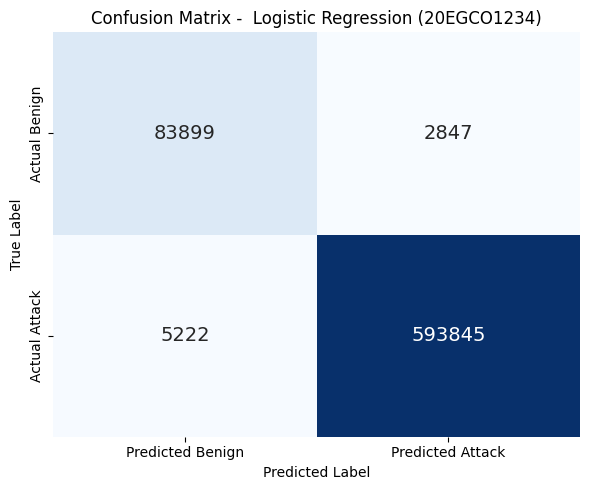

In [66]:
# Visualise the confusion matrix using a heatmap
# Visit "https://seaborn.pydata.org/generated/seaborn.heatmap.html" for more info on sns.heatmap

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, # Change true to false and vice versa to switch color bar
            xticklabels=['Predicted Benign', 'Predicted Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'],
            annot_kws={"fontsize": 14})
plt.title("Confusion Matrix -  Logistic Regression (20EGCO1234)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(results_dir / "confusion_matrix.png", dpi=400)
plt.show()

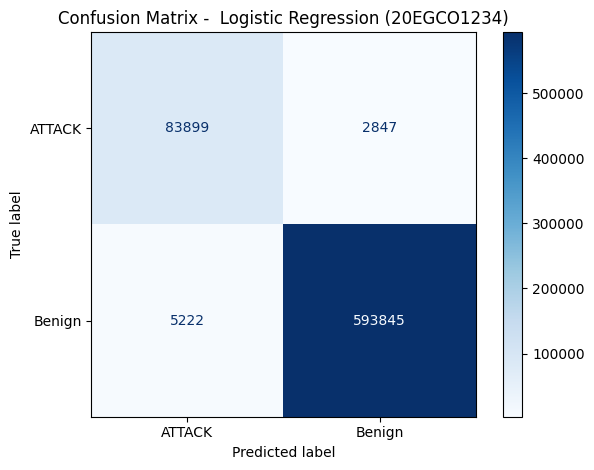

In [67]:
# You can also use the ConfusionMatrixDisplay from sklearn for visualization
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html" for more info on ConfusionMatrixDisplay

from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix -  Logistic Regression (20EGCO1234)")
plt.tight_layout()
plt.savefig(results_dir / "confusion_matrix_display.png", dpi=400)
plt.show()

In [68]:
# Get the confusion matrix values
# Visit "https://numpy.org/doc/stable/reference/generated/numpy.ndarray.ravel.html" for more info on np.ndarray.ravel
# You can also use cm.flatten() instead of cm.ravel()
# Visit "https://numpy.org/doc/stable/reference/generated/numpy.ndarray.flatten.html" for more info on np.ndarray.flatten

TN, FP, FN, TP = cm.ravel()

print(f"True Negatives: {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"True Positives: {TP}")

True Negatives: 83899
False Positives: 2847
False Negatives: 5222
True Positives: 593845


In [69]:
# Visualise the classification report
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html" for more info on classification_report

from sklearn.metrics import classification_report

# Retrieve class names from the label encoder
class_names = label_encoder.classes_ 

report = classification_report(y_test, y_pred, 
                                target_names=class_names,
                                digits=4)
print("Classification Report  -  Logistic Regression (20EGCO1234):\n", report)

Classification Report  -  Logistic Regression (20EGCO1234):
               precision    recall  f1-score   support

      ATTACK     0.9414    0.9672    0.9541     86746
      Benign     0.9952    0.9913    0.9933    599067

    accuracy                         0.9882    685813
   macro avg     0.9683    0.9792    0.9737    685813
weighted avg     0.9884    0.9882    0.9883    685813



In [70]:
# Compute accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC
# Visit "https://scikit-learn.org/stable/modules/model_evaluation.html" for more info on model evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,            
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall_vals, precision_vals)


print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

Accuracy: 0.9882
Precision: 0.9952
Recall: 0.9913
F1-Score: 0.9933
ROC-AUC: 0.9990
PR-AUC: 0.9999


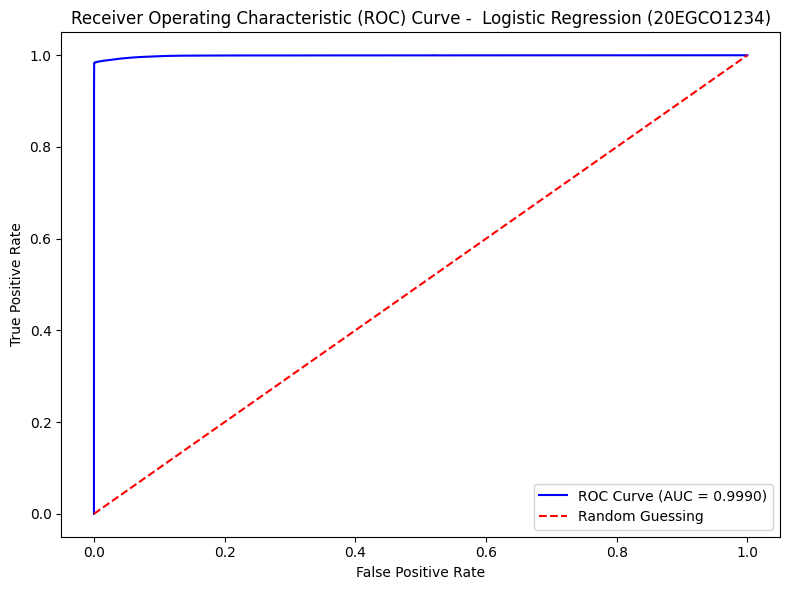

In [71]:
# Visualise the ROC Curve
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html" for more info on roc_curve

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.title("Receiver Operating Characteristic (ROC) Curve -  Logistic Regression (20EGCO1234)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(results_dir / "roc_curve.png", dpi=400)
plt.show()

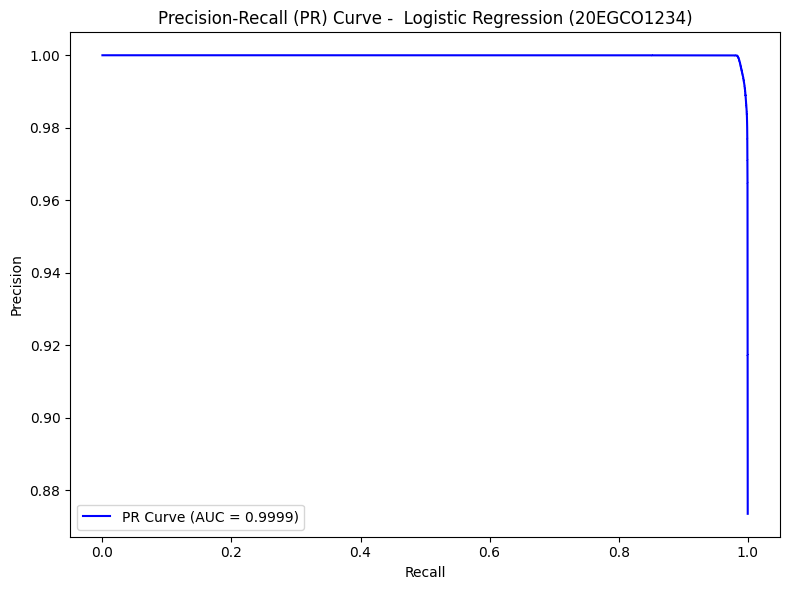

In [72]:
# Visualise the PR Curve
# Visit "https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html" for more info on precision_recall_curve

from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='blue', label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.title("Precision-Recall (PR) Curve -  Logistic Regression (20EGCO1234)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(results_dir / "pr_curve.png", dpi=400)
plt.show() 